# NLP + Finance: Exploratory Data Analysis

This notebook explores the Financial PhraseBank dataset — 
~4,800 financial news headlines annotated with sentiment labels.

**Goal:** Understand the data before building any models.
- What does the class distribution look like?
- Are there class imbalance issues?
- What do positive, negative, and neutral headlines look like?

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../data/raw/all-data.csv', 
                 encoding='latin-1', 
                 header=None,
                 names=['sentiment', 'headline'])

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape: (4846, 2)

First 5 rows:
  sentiment                                           headline
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...


sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

Class percentages:
sentiment
neutral     59.4
positive    28.1
negative    12.5
Name: count, dtype: float64


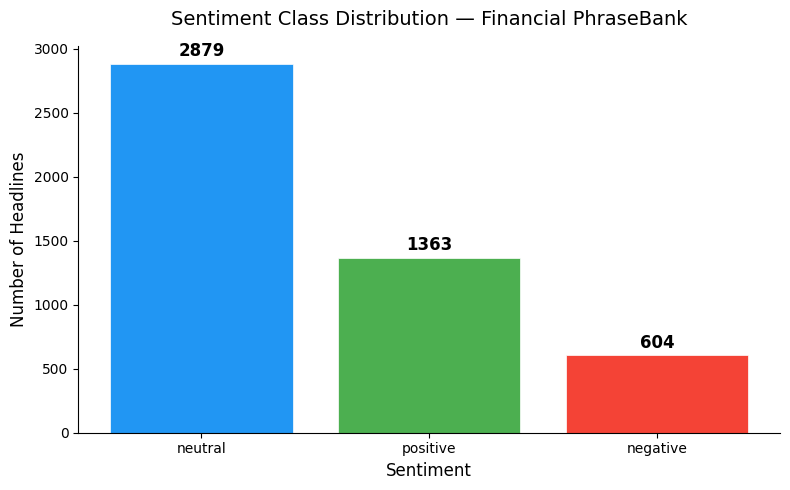

Chart saved to images/


In [4]:
import matplotlib.pyplot as plt

# Count each sentiment class
class_counts = df['sentiment'].value_counts()
print(class_counts)
print(f"\nClass percentages:")
print((class_counts / len(df) * 100).round(1))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2196F3', '#4CAF50', '#F44336']
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, 
            str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Sentiment Class Distribution — Financial PhraseBank', fontsize=14, pad=15)
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Headlines', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images/")

## What I notice about the class distribution

the dataset is really imbalanced - neutral takes up nearly 60% 
which i didn't expect. negative is only 12.5% which is a problem 
because that's actually the most important class for trading. if 
the model just guesses neutral every time it would still be "right" 
60% of the time which is why accuracy is basically useless here. 
switching to weighted F1 instead.

also, a model that misses negative headlines could literally 
generate a BUY signal right before bad news hits. that's the 
worst possible outcome for a trading system.

In [5]:
# Headline length analysis
df['headline_length'] = df['headline'].apply(lambda x: len(x.split()))

# Print average length per class
print("Average headline length by sentiment:")
print(df.groupby('sentiment')['headline_length'].mean().round(1))
print(f"\nOverall average: {df['headline_length'].mean().round(1)} words")

Average headline length by sentiment:
sentiment
negative    23.9
neutral     22.2
positive    24.7
Name: headline_length, dtype: float64

Overall average: 23.1 words


honestly, expected positive or negative headlines to be longer 
since they'd need more context to convey strong sentiment - but 
the averages are almost the same across all three classes(~22-25 words). 
Length alone won't be a useful feature for the model.

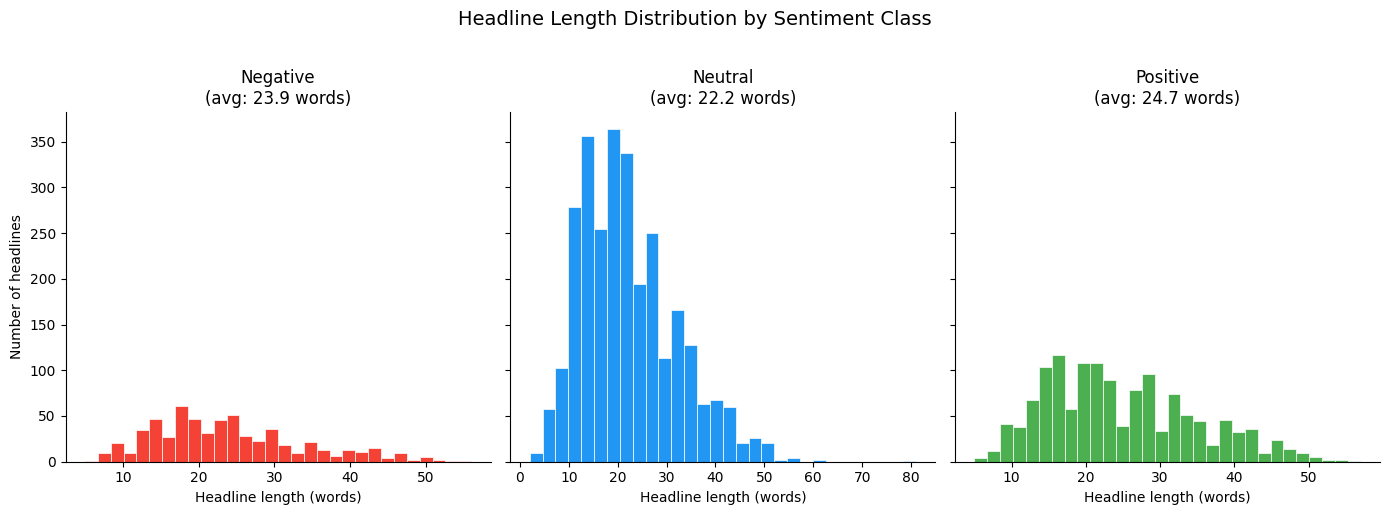

Chart saved.


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
colors = {'negative': '#F44336', 'neutral': '#2196F3', 'positive': '#4CAF50'}

for ax, sentiment in zip(axes, ['negative', 'neutral', 'positive']):
    subset = df[df['sentiment'] == sentiment]['headline_length']
    ax.hist(subset, bins=30, color=colors[sentiment], edgecolor='white', linewidth=0.5)
    ax.set_title(f'{sentiment.capitalize()}\n(avg: {subset.mean():.1f} words)', fontsize=12)
    ax.set_xlabel('Headline length (words)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Number of headlines')
fig.suptitle('Headline Length Distribution by Sentiment Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../images/headline_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

one thing i noticed : the neutral histogram has a much sharper 
peak and longer tail than negative or positive. neutral headlines 
seem to cluster tightly around 15-20 words but occasionally get 
very long. not sure what to make of that yet.